# Data_Create Model Data-gSST

August 26, 2022, updated Feb 3, 2025

Caroline Juang, c.juang@columbia.edu

The data is already prepared to some extent. Make sure the other two things are run:
* `Data_CreateENSOIndex.ipynb`: for the SST gradients
* `Ecoprovinces_ExtendData.ipynb`: for summing MODIS and WUMI by all, forest, nonforest and by ecoregion

Prepare all the gSST indices for training the model. This file should be run manually multiple times (by changing the `climindname` string) to output every single index needed.
* SST for 1982 to present
    * observed
    * detrended (by season)
* SST 1981 to present (for visualizations)
    * observed
    * detrended (by season)

User inputs: 
* present = should be defined
* seasons = defined

In [1]:
# import
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

## Define climindname (SST gradient climate index) here!!!!!!

Comment in the name of the gSST to create, and comment out the other ones.

In [2]:
#climindname = 'mei_noaa'
#climindname = 'patch125-155_nino3-34' # gradient: (125-155 deg lon) - nino3.4 (190-240 deg)
#climindname = 'pdo_noaa'
#climindname = 'soi_noaa'
#climindname = 'patch125-155_nino3-34a'
#climindname = 'patch125-155_nino3-34b'
#climindname = 'patch125-155_nino3-34c'
climindname = 'patch125-155_nino3-34d'

# unused
#climindname = 'pdo_jma'
#climindname = 'karnauskas2009'
#climindname = 'patch125-155_nino34'

## User input

In [3]:
# customize seasons for climate variables

# customize number of rolling periods
ant_years = 1 # antecedent years to include (2 antecedent years + current year)
ant_season = 3 # n+1 of months to include in each period (e.g. input 2 would mean 3 months)

firstyear = 1984 # first year of data
finalyear = 2022 # final year of all data (should be same as burned area)
wumiyear = 2020 # final year of wumi data
time_length = int(finalyear-firstyear+1) # get length of timeseries
# translate years into dates (for climate variables)
firsttime = str(firstyear-ant_years)+'-01-01'
finaltime = str(finalyear)+'-12-31'

# importing data string
#directory = 'C:\\Users\\carol\\Documents\\Research Data 2020\\'
directory = '//Users//caroline//Documents//Research Data 2020//'

# for climate variables
#primary_string = '12km\\climate\\primary\\'
primary_string = '12km//climate//primary//'

In [4]:
# create strings of the types of forests, remove #5
province_names = ['1: American Semi-Desert and Desert Province',
                  '2: Arizona-New Mexico Mountains Semi-Desert-Open Woodland-Coniferous Forest-Alpine Meadow Province',
                  '3: Black Hills Coniferous Forest Province',
                  '4: California Coastal Chapparral Forest and Shrub Province',
                  '5: California Coastal Range Open Woodland-Shrub-Coniferous Forest-Meadow Province',
                  '6: California Coastal Steppe-Mixed Forest-Redwood Forest Province',
                  '7: California Dry Steppe Province',
                  '8: Cascade Mixed Forest-Coniferous Forest-Alpine Meadow Province',
                  '9: Chihuahuan Semi-Desert Province',
                  '10: Colorado Plateau Semi-Desert Province',
                  '12: Great Plains-Palouse Dry Steppe Province',
                  '13: Intermountain Semi-Desert Province',
                  '14: Intermountain Semi-Desert and Desert Province',
                  '15: Middle Rocky Mountain Steppe-Coniferous Forest-Alpine Meadow Province',
                  '16: Nevada-Utah Mountains-Semi-Desert-Coniferous Forest-Alpine Meadow Province',
                  '17: Northern Rocky Mountain Forest-Steppe-Coniferous Forest-Alpine Meadow Province',
                  '18: Pacific Lowland Mixed Forest Province',
                  '19: Sierran Steppe-Mixed Forest-Coniferous Forest-Alpine Meadow Province',
                  '20: Southern Rocky Mountain Steppe-Open Woodland-Coniferous Forest-Alpine Meadow Province',
                  '21: Southwest Plateau and Plains Dry Steppe and Shrub Province']
province_num = [item for item in range(len(province_names)+1+1)]
province_num.remove(11) # remove empty ecoregion - no overlap btwn westUS map and ecoregion
dfnames = ['allwestUS', 'ecoprov1', 'ecoprov2', 'ecoprov3', 'ecoprov4', 'ecoprov5', 
           'ecoprov6', 'ecoprov7', 'ecoprov8', 'ecoprov9', 'ecoprov10', 
           'ecoprov12','ecoprov13','ecoprov14','ecoprov15',
           'ecoprov16','ecoprov17','ecoprov18','ecoprov19','ecoprov20','ecoprov21']

## Scripts

In [5]:
# average climate variables, within a selected season

def annual_seasonAvg(data, firstmonth, finalmonth):
    """
    This intakes an array of current ecoregion's climate variable of monthly averages (data), 
    Output: an array of yearly averages of the ecoregion climate variable, in the
    seasons specified (firstmonth, finalmonth).
    Requirements: time = an xarray timeseries of months in datetime format.
    """
    withinyear = (time['time.year']>= years[0]) & (time['time.year'] <= years[-1])
    withinseason = (time['time.month'] >= firstmonth) & (time['time.month'] <= finalmonth)
    thistime = time[withinseason & withinyear] # cut time

    # create pd dataframe based on data, for time resampling
    thisdf = pd.DataFrame({'time': pd.to_datetime(thistime.values), 'clim':data[withinyear & withinseason]}).set_index('time')
    thisdf = thisdf.resample('Y').mean().reset_index()
    return thisdf.clim.values

In [6]:
# average climate variables, within a selected season

def annual_seasonAvgDT(data, firstmonth, finalmonth):
    """
    This intakes an array of current ecoregion's climate variable of monthly averages (data), 
    Output: a normalized array of yearly averages of the ecoregion climate variable, in the
    seasons specified (firstmonth, finalmonth). The data is detrended by removing the slope of
    the original seasonal data.
    Requirements: time = an xarray timeseries of months in datetime format.
    """
    withinyear = (time['time.year']>= years[0]) & (time['time.year'] <= years[-1])
    withinseason = (time['time.month'] >= firstmonth) & (time['time.month'] <= finalmonth)
    thistime = time[withinseason & withinyear] # cut time

    # detrend the data
    tmpdata = data[withinyear & withinseason]
    xnum = np.arange(0,len(thistime))
    reg = linregress(xnum, tmpdata)
    m = reg.slope
    b = reg.intercept
    regpredict = m*xnum + b
    # normalize by subtracting the linear regression
    tmpdatanorm = (tmpdata - regpredict) + b

    # create pd dataframe based on data, for time resampling
    thisdf = pd.DataFrame({'time': pd.to_datetime(thistime.values), 'clim':tmpdatanorm}).set_index('time')
    thisdf = thisdf.resample('Y').mean().reset_index()
    return thisdf.clim.values

In [7]:
# average climate variables, within a selected season

def annual_seasonSum(data, firstmonth, finalmonth):
    """
    This intakes an array of current ecoregion's climate variable of monthly averages (data), 
    Output: an array of yearly averages of the ecoregion climate variable, in the
    seasons specified (firstmonth, finalmonth).
    Requirements: time = an xarray timeseries of months in datetime format.
    """
    withinyear = (time['time.year']>= years[0]) & (time['time.year'] <= years[-1])
    withinseason = (time['time.month'] >= firstmonth) & (time['time.month'] <= finalmonth)
    thistime = time[withinseason & withinyear] # cut time
    
    # create pd dataframe based on data, for time resampling
    thisdf = pd.DataFrame({'time': pd.to_datetime(thistime.values), 'clim':data[withinyear & withinseason]}).set_index('time')
    thisdf = thisdf.resample('Y').sum().reset_index()
    return thisdf.clim.values

In [8]:
# get amount in forest

def in_allregion(variable, thisregion):
    """
    For getting the average values only in this particular region of the western US.
    Requirements: the western US study area.
    Returns one weighted average of the variable for each timestep.
    """
    thisregion = westUS*thisregion # get in the study area
    weightedsum = (variable*thisregion).sum(dim=['X','Y'], skipna=True)
    regionsum = thisregion.sum()
    return  weightedsum / regionsum

def in_forest(variable, thisregion):
    """
    For getting the average values only in a forest area.
    Requirements: the forest netCDF.
    Returns one weighted average of the variable for each timestep.
    """
    forestregion = forest*thisregion # get in the region
    weightedsum = (variable*(forestregion)).sum(dim=['X','Y'], skipna=True)
    forestsum = (forestregion).sum()
    return  weightedsum / forestsum


def in_nonforest(variable, thisregion):
    """
    For getting the average values only in a nonforested area in the western US.
    Requirements: the forest netCDF, a mask of the western US.
    Returns one weighted average of the variable for each timestep and the selected region.
    """
    nonforestregion = nonforest*thisregion # get in the region
    weightedsum = (variable*(nonforestregion)).sum(dim=['X','Y'], skipna=True)
    nonforestsum = (nonforestregion).sum()
    return  weightedsum / nonforestsum

# import data

In [9]:
# import western US study area
#westUS_string = directory + '12km\\study_area\\westUS.nc'
westUS_string = directory + '12km//study_area//westUS.nc'
westUS = xr.open_dataset(westUS_string, engine='netcdf4')
westUS = westUS.westUS

# import forest
#forest_string = directory + '12km\\landcover\\US_ForestType_Ruefenacht\\forest_type_frac.nc'
forest_string = directory + '12km//landcover//US_ForestType_Ruefenacht//forest_type_frac.nc'
forest = xr.open_dataset(forest_string, engine='netcdf4')
forest = forest.forest_type_frac.sum(dim='ftype') # sum over all forest types

# create forest and nonforest area 
forest = westUS*forest
nonforest = westUS*(1-forest)
# add province as dimension to the westUS, to combine with ecoregions
westUS = westUS.expand_dims({'province':[0]})

In [10]:
# Bailey's ecoprovinces
#ecoreg_string = directory + '12km\\landcover\\Ecoregions_EPA\\bailey_ecoprovince.nc'
ecoreg_string = directory + '12km//landcover//Ecoregions_EPA//bailey_ecoprovince.nc'
ecoreg = xr.open_dataset(ecoreg_string, engine='netcdf4')
print(ecoreg.bailey_ecoprovince.province.legend)

# add in entire western US
ecoreg = xr.concat([westUS, ecoreg.bailey_ecoprovince], dim='province')
# remove the ecoregion that does not overlap with the western US
ecoreg = ecoreg.sel(province=province_num)

1: American Semi-Desert and Desert Province, 2: Arizona-New Mexico Mountains Semi-Desert-Open Woodland-Coniferous Forest-Alpine Meadow Province, 3: Black Hills Coniferous Forest Province, 4: California Coastal Chapparral Forest and Shrub Province, 5: California Coastal Range Open Woodland-Shrub-Coniferous Forest-Meadow Province, 6: California Coastal Steppe-Mixed Forest-Redwood Forest Province, 7: California Dry Steppe Province, 8: Cascade Mixed Forest-Coniferous Forest-Alpine Meadow Province, 9: Chihuahuan Semi-Desert Province, 10: Colorado Plateau Semi-Desert Province, 11: Great Plains Steppe Province, 12: Great Plains-Palouse Dry Steppe Province, 13: Intermountain Semi-Desert Province, 14: Intermountain Semi-Desert and Desert Province, 15: Middle Rocky Mountain Steppe-Coniferous Forest-Alpine Meadow Province, 16: Nevada-Utah Mountains-Semi-Desert-Coniferous Forest-Alpine Meadow Province, 17: Northern Rocky Mountain Forest-Steppe-Coniferous Forest-Alpine Meadow Province, 18: Pacific 

# SST Gradient (1982 to present-1, 1983 to present)

## climind_seasons (1982 to present-1, 1983 to present)

**Swap out the `climindname` variable to the correct one to update**

For predicting concurrent-year variables

In [11]:
firstyearclim = firstyear-ant_years-1
filename = 'gradient_'+climindname+'.txt'
print(filename)
climind = pd.read_csv(filename, header=None, sep=",", skiprows=[0]).set_index(0)
climind = climind.loc[(firstyearclim):finalyear] # crop
print('cropped data to '+str(firstyearclim)+' to '+str(finalyear))



# get dates associated with beginning of every 3 months
firstdate = str(firstyearclim)+'-01-15'
lastdate = str(finalyear+1)+'-01-15'
ninodate = pd.to_datetime(pd.date_range(start=firstdate, end=lastdate, freq='M'), unit='M')
ninotime = pd.DatetimeIndex(ninodate, freq='1M')
# flatten
climind = climind.to_numpy().flatten()
# create pd dataframe
climind_df = pd.DataFrame(data={'time': ninodate, 'anomaly': climind}).set_index('time')

gradient_patch125-155_nino3-34d.txt
cropped data to 1982 to 2022


In [12]:
# a few definitions to help the for-loop

# get years of data to look at
year_rolls = np.arange(-ant_years, 1, 1)

# this is number of seasons (based on user inputs)
firstmonth = np.arange(1, (12*ant_years), ant_season)
finalmonth = np.arange(ant_season, (12*ant_years+ant_season), ant_season)
lastdate = str(finalyear)+'-12-15'

prec2 = xr.open_dataset(directory + primary_string + 'prec.nc')
prec2 = prec2.prec.loc[firstdate:lastdate]
time = prec2.time # xarray datetime format

In [13]:
# create a timeseries of just all the observed SST by season

ant_rolls = int(12/ant_season)
obs_tot = np.zeros((time_length+2, ant_rolls)) # years, rolling periods

# define the seasons and years
firstmonth = np.arange(1, 12, ant_season)
finalmonth = np.arange(ant_season, 12+1, ant_season)
years = np.arange(firstyearclim, finalyear+1)

labels = []
icol=0
for index in np.arange(len(firstmonth)):
    print(climindname+ ' index from '+str(years[0])+'-'+str(years[-1]))
    climavg = annual_seasonAvg(climind_df.anomaly.values, firstmonth[index], finalmonth[index])
    # create string description
    label = 'y0 mo ' + str(firstmonth[index])+'-'+str(finalmonth[index] ) 
    labels.append(label)
    print(label)
    # put this rolling period in the overall storage
    obs_tot[:,icol] = climavg
    icol+=1

# put into dataframe
climind82_seasons = pd.DataFrame(obs_tot, index=years, columns=labels)

patch125-155_nino3-34d index from 1982-2022
y0 mo 1-3
patch125-155_nino3-34d index from 1982-2022
y0 mo 4-6
patch125-155_nino3-34d index from 1982-2022
y0 mo 7-9
patch125-155_nino3-34d index from 1982-2022
y0 mo 10-12


In [14]:
# split the data into prior and concurrent seasons
ant_rolls = int((ant_years+1)*12/ant_season)

# storage; rolling average SSTs
sst_avg_roll = np.zeros((time_length+1, ant_rolls)) # years, rolling periods
labels = [] # labels for each col

icol = 0 # column index
# go through EACH ROLLING PERIOD
for prev in year_rolls:
    years = np.arange(firstyear+prev-1, finalyear+prev+1, 1)
    print(climindname+' index from '+str(years[0])+'-'+str(years[-1]))
    for index in np.arange(len(firstmonth)):
        climavg = annual_seasonAvg(climind_df.anomaly.values, firstmonth[index], finalmonth[index])
        # create string description
        label = 'y'+str(prev)+' mo ' + str(firstmonth[index])+'-'+str(finalmonth[index] ) 
        labels.append(label)
        print(label)
        # put this rolling period in the overall storage
        sst_avg_roll[:,icol] = climavg
        icol+=1
# put into dataframe
climind83_seasons = pd.DataFrame(sst_avg_roll, index=None, columns=labels)

patch125-155_nino3-34d index from 1982-2021
y-1 mo 1-3
y-1 mo 4-6
y-1 mo 7-9
y-1 mo 10-12
patch125-155_nino3-34d index from 1983-2022
y0 mo 1-3
y0 mo 4-6
y0 mo 7-9
y0 mo 10-12


In [15]:
# save data
climind82_seasons.to_csv('sstgrad_seasonfull_' +climindname+'_82_y.txt')
print('exported sstgrad_seasonfull_' +climindname+'_82_y.txt')
climind83_seasons.to_csv('sstgrad_seasons_' +climindname +'_82_y.txt')
print('exported sstgrad_seasons_' +climindname+'_82_y.txt')

# print last time the data was updated
from datetime import datetime
# datetime object containing current date and time
now = datetime.now()
# dd/mm/YY H:M:S
dt_string = now.strftime("%d/%m/%Y %H:%M:%S")
print("Data last updated for",climindname,"=", dt_string)

exported sstgrad_seasonfull_patch125-155_nino3-34d_82_y.txt
exported sstgrad_seasons_patch125-155_nino3-34d_82_y.txt
Data last updated for patch125-155_nino3-34d = 21/10/2025 12:23:52


## DETRENDED climind_seasons (1982 to present-1, 1983 to present)

**Swap out the `climindname` variable to the correct one to update**

1. The entire 1982-2021 trendline is detrended by 3-month season by removing the slope from each season's data (from the previous part)
2. The data is split into prior-season and current-season variables by either selecting years 1982-2020 or 1983-2021.

In [16]:
# gradient: (125-155 deg lon) - nino3.4 (190-240 deg)
climindfilename = 'DeTrend_'+climindname
filename = 'gradient_'+climindname+'.txt'
print(filename)
firstyearclim = firstyear-ant_years-1
climind = pd.read_csv(filename, header=None, sep=",", skiprows=[0]).set_index(0)
climind = climind.loc[(firstyearclim):finalyear] # crop
print('cropped data to '+str(firstyearclim)+' to '+str(finalyear))

# get dates associated with beginning of every 3 months
firstdate = str(firstyearclim)+'-01-15'
lastdate = str(finalyear+1)+'-01-15'
ninodate = pd.to_datetime(pd.date_range(start=firstdate, end=lastdate, freq='M'), unit='M')
ninotime = pd.DatetimeIndex(ninodate, freq='1M')
# flatten
climind = climind.to_numpy().flatten()
# create pd dataframe
climind_df = pd.DataFrame(data={'time': ninodate, 'anomaly': climind}).set_index('time')

gradient_patch125-155_nino3-34d.txt
cropped data to 1982 to 2022


In [17]:
# a few definitions to help the for-loop

# get years of data to look at
year_rolls = np.arange(-ant_years, 1, 1)

# this is number of seasons (based on user inputs)
firstmonth = np.arange(1, 12, ant_season)
finalmonth = np.arange(ant_season, 12+1, ant_season)
lastdate = str(finalyear)+'-12-15'

prec2 = xr.open_dataset(directory + primary_string + 'prec.nc')
prec2 = prec2.prec.loc[firstdate:lastdate]
time = prec2.time # xarray datetime format

In [18]:
# DETREND the entire timeseries by season (1982-2021)

ant_rolls = int(12/ant_season)
detrend_tot = np.zeros((time_length+2, ant_rolls)) # years, rolling periods

# define the seasons
firstmonth = np.arange(1, 12, ant_season)
finalmonth = np.arange(ant_season, 12+1, ant_season)
lastdate = str(finalyear)+'-12-15'
prec2 = xr.open_dataset(directory + primary_string + 'prec.nc')
prec2 = prec2.prec.loc[firstdate:lastdate]
years = np.arange(firstyearclim, finalyear+1)

labels = []
icol=0
for index in np.arange(len(firstmonth)):
    print(climindname+' index from '+str(years[0])+'-'+str(years[-1]))
    climavg = annual_seasonAvgDT(climind_df.anomaly.values, firstmonth[index], finalmonth[index])
    # create string description
    label = 'y0 mo ' + str(firstmonth[index])+'-'+str(finalmonth[index] ) 
    labels.append(label)
    print(label)
    # put this rolling period in the overall storage
    detrend_tot[:,icol] = climavg
    icol+=1

# put into dataframe
climind82_seasonsDT = pd.DataFrame(detrend_tot, index=years, columns=labels)

patch125-155_nino3-34d index from 1982-2022
y0 mo 1-3
patch125-155_nino3-34d index from 1982-2022
y0 mo 4-6
patch125-155_nino3-34d index from 1982-2022
y0 mo 7-9
patch125-155_nino3-34d index from 1982-2022
y0 mo 10-12


slopes of y-1 mo 1-3	m1: 0.027	m2: 0.00091
slopes of y-1 mo 4-6	m1: 0.018	m2: -0.00033
slopes of y-1 mo 7-9	m1: 0.026	m2: -0.00058
slopes of y-1 mo 10-12	m1: 0.03	m2: -2.2e-05


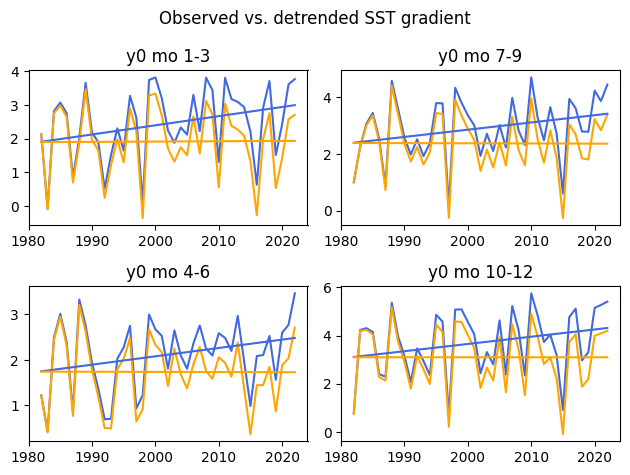

In [19]:
# plot both SST gradients and compare
fig, ax = plt.subplots(2,2)
icol = 0
for i in np.arange(0,2):
    for j in np.arange(0,2):
        tmpindex = np.array(climind82_seasons.iloc[:,icol].index)
        tmpobs = np.array(climind82_seasons.iloc[:,icol])
        tmpDT = np.array(climind82_seasonsDT.iloc[:,icol])
        ax[j,i].plot(tmpindex, tmpobs, label='obs', c='royalblue')
        ax[j,i].plot(tmpindex, tmpDT, label='DT', c='orange')
        ax[j,i].set_title(climind82_seasons.columns[icol])
        # show trendlines
        reg = linregress(tmpindex, tmpobs)
        m = reg.slope
        b = reg.intercept
        regpredict = m*tmpindex + b
        reg2 = linregress(tmpindex, tmpDT)
        m2 = reg2.slope
        b2 = reg2.intercept
        reg2predict = m2*tmpindex + b2
        print('slopes of '+climind83_seasons.columns[icol]+'\t'+'m1: {:.2}\tm2: {:.2}'.format(m, m2))
        ax[j,i].plot(tmpindex, regpredict, label='pos. lin. trend', c='royalblue')
        ax[j,i].plot(tmpindex, reg2predict, label='normalized trend', c='orange')
        icol+=1
fig.suptitle('Observed vs. detrended SST gradient')
fig.tight_layout()

In [20]:
# split the data into the inputs

ant_rolls = int((ant_years+1)*12/ant_season)

# storage; rolling average SSTs
sst_avg_roll = np.zeros((time_length+1, ant_rolls)) # years, rolling periods
labels = [] # labels for each col

icol = 0 # column index
# go through EACH ROLLING PERIOD
for prev in year_rolls:
    years = np.arange(firstyear+prev-1, finalyear+prev+1, 1)
    print(climindname+' index from '+str(years[0])+'-'+str(years[-1]))
    for index in np.arange(len(firstmonth)):
        # grab season from df within correct years
        thisseason = 'y0'+' mo ' + str(firstmonth[index])+'-'+str(finalmonth[index] )
        climavg = climind82_seasonsDT.loc[years[0]:years[-1],thisseason]
        # create string description
        label = 'y'+str(prev)+' mo ' + str(firstmonth[index])+'-'+str(finalmonth[index] ) 
        labels.append(label)
        print(label)
        # put this rolling period in the overall storage
        sst_avg_roll[:,icol] = climavg
        icol+=1
# put into dataframe
climind83_seasonsDT = pd.DataFrame(sst_avg_roll, index=None, columns=labels)
print(np.shape(climind83_seasonsDT))

patch125-155_nino3-34d index from 1982-2021
y-1 mo 1-3
y-1 mo 4-6
y-1 mo 7-9
y-1 mo 10-12
patch125-155_nino3-34d index from 1983-2022
y0 mo 1-3
y0 mo 4-6
y0 mo 7-9
y0 mo 10-12
(40, 8)


In [21]:
# save data
climind82_seasonsDT.to_csv('sstgrad_seasonfull_' +climindfilename+'_82_y.txt')
print('exported sstgrad_seasonfull_' +climindfilename+'_82_y.txt')
climind83_seasonsDT.to_csv('sstgrad_seasons_' +climindfilename+'_82_y.txt')
print('exported sstgrad_seasons_' +climindfilename+'_82_y.txt')

# print last time the data was updated
from datetime import datetime

# datetime object containing current date and time
now = datetime.now()
# dd/mm/YY H:M:S
dt_string = now.strftime("%d/%m/%Y %H:%M:%S")
print("Data last updated for",climindname,"=", dt_string)

exported sstgrad_seasonfull_DeTrend_patch125-155_nino3-34d_82_y.txt
exported sstgrad_seasons_DeTrend_patch125-155_nino3-34d_82_y.txt
Data last updated for patch125-155_nino3-34d = 21/10/2025 12:23:52


slopes of y-1 mo 1-3	m1: 0.024	m2: -0.0021
slopes of y-1 mo 4-6	m1: 0.015	m2: -0.0041
slopes of y-1 mo 7-9	m1: 0.022	m2: -0.0045
slopes of y-1 mo 10-12	m1: 0.026	m2: -0.0042
slopes of y0 mo 1-3	m1: 0.028	m2: 0.0018
slopes of y0 mo 4-6	m1: 0.016	m2: -0.0023
slopes of y0 mo 7-9	m1: 0.02	m2: -0.0059
slopes of y0 mo 10-12	m1: 0.021	m2: -0.0091


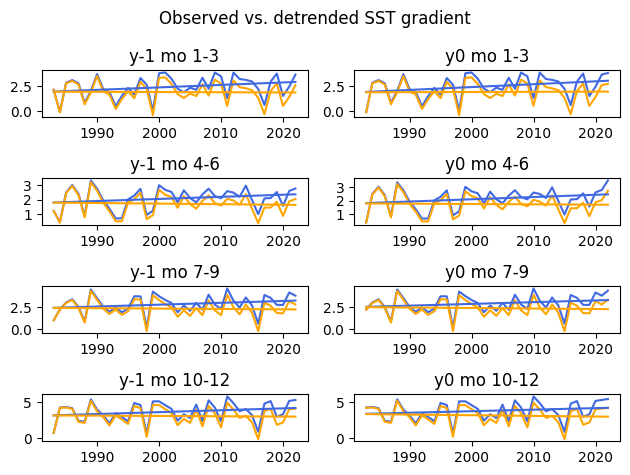

In [22]:
# plot both SST gradients and compare
fig, ax = plt.subplots(4,2)
icol = 0
for i in np.arange(0,2):
    for j in np.arange(0,4):
        tmpobs = np.array(climind83_seasons.iloc[:,icol])
        tmpDT = np.array(climind83_seasonsDT.iloc[:,icol])
        ax[j,i].plot(years, tmpobs, label='obs', c='royalblue')
        ax[j,i].plot(years, tmpDT, label='DT', c='orange')
        ax[j,i].set_title(climind83_seasons.columns[icol])
        # show trendlines
        reg = linregress(years, tmpobs)
        m = reg.slope
        b = reg.intercept
        regpredict = m*years + b
        reg2 = linregress(years, tmpDT)
        m2 = reg2.slope
        b2 = reg2.intercept
        reg2predict = m2*years + b2
        print('slopes of '+climind83_seasons.columns[icol]+'\t'+'m1: {:.2}\tm2: {:.2}'.format(m, m2))
        ax[j,i].plot(years, regpredict, label='pos. lin. trend', c='royalblue')
        ax[j,i].plot(years, reg2predict, label='normalized trend', c='orange')
        icol+=1
fig.suptitle('Observed vs. detrended SST gradient')
fig.tight_layout()

# SST Gradient (1981 to present-1, 1982 to present)

## climind_seasons (1981 to present-1, 1982 to present)

**Swap out the `climindname` variable to the correct one to update**

For predicting concurrent-year variables

Extended SST gradient dataset, for predicting longer timeseries of data of climate datasets

In [23]:
firstyearclim = firstyear-ant_years-2 # changed the number of years
filename = 'gradient_'+climindname+'.txt'
print(filename)
climind = pd.read_csv(filename, header=None, sep=",", skiprows=[0]).set_index(0)
climind = climind.loc[(firstyearclim):finalyear] # crop
print('cropped data to '+str(firstyearclim)+' to '+str(finalyear))



# get dates associated with beginning of every 3 months
firstdate = str(firstyearclim)+'-01-15'
lastdate = str(finalyear+1)+'-01-15'
ninodate = pd.to_datetime(pd.date_range(start=firstdate, end=lastdate, freq='M'), unit='M')
ninotime = pd.DatetimeIndex(ninodate, freq='1M')
# flatten
climind = climind.to_numpy().flatten()
# create pd dataframe
climind_df = pd.DataFrame(data={'time': ninodate, 'anomaly': climind}).set_index('time')

gradient_patch125-155_nino3-34d.txt
cropped data to 1981 to 2022


In [24]:
# a few definitions to help the for-loop

# get years of data to look at
year_rolls = np.arange(-ant_years, 1, 1)

# this is number of seasons (based on user inputs)
firstmonth = np.arange(1, (12*ant_years), ant_season)
finalmonth = np.arange(ant_season, (12*ant_years+ant_season), ant_season)
lastdate = str(finalyear)+'-12-15'

prec2 = xr.open_dataset(directory + primary_string + 'prec.nc')
prec2 = prec2.prec.loc[firstdate:lastdate]
time = prec2.time # xarray datetime format

In [25]:
# create a timeseries of just all the observed SST by season

ant_rolls = int(12/ant_season)
obs_tot = np.zeros((time_length+3, ant_rolls)) # years, rolling periods

# define the seasons and years
firstmonth = np.arange(1, 12, ant_season)
finalmonth = np.arange(ant_season, 12+1, ant_season)
years = np.arange(firstyearclim, finalyear+1)

labels = []
icol=0
for index in np.arange(len(firstmonth)):
    print(climindname+ ' index from '+str(years[0])+'-'+str(years[-1]))
    climavg = annual_seasonAvg(climind_df.anomaly.values, firstmonth[index], finalmonth[index])
    # create string description
    label = 'y0 mo ' + str(firstmonth[index])+'-'+str(finalmonth[index] ) 
    labels.append(label)
    print(label)
    # put this rolling period in the overall storage
    obs_tot[:,icol] = climavg
    icol+=1

# put into dataframe
climind82_seasons = pd.DataFrame(obs_tot, index=years, columns=labels)

patch125-155_nino3-34d index from 1981-2022
y0 mo 1-3
patch125-155_nino3-34d index from 1981-2022
y0 mo 4-6
patch125-155_nino3-34d index from 1981-2022
y0 mo 7-9
patch125-155_nino3-34d index from 1981-2022
y0 mo 10-12


In [26]:
# split the data into prior and concurrent seasons
ant_rolls = int((ant_years+1)*12/ant_season)

# storage; rolling average SSTs
sst_avg_roll = np.zeros((time_length+2, ant_rolls)) # years, rolling periods
labels = [] # labels for each col

icol = 0 # column index
# go through EACH ROLLING PERIOD
for prev in year_rolls:
    years = np.arange(firstyear+prev-2, finalyear+prev+1, 1)
    print(climindname+ ' index from '+str(years[0])+'-'+str(years[-1]))
    for index in np.arange(len(firstmonth)):
        climavg = annual_seasonAvg(climind_df.anomaly.values, firstmonth[index], finalmonth[index])
        # create string description
        label = 'y'+str(prev)+' mo ' + str(firstmonth[index])+'-'+str(finalmonth[index] ) 
        labels.append(label)
        print(label)
        # put this rolling period in the overall storage
        sst_avg_roll[:,icol] = climavg
        icol+=1
# put into dataframe
climind83_seasons = pd.DataFrame(sst_avg_roll, index=None, columns=labels)

patch125-155_nino3-34d index from 1981-2021
y-1 mo 1-3
y-1 mo 4-6
y-1 mo 7-9
y-1 mo 10-12
patch125-155_nino3-34d index from 1982-2022
y0 mo 1-3
y0 mo 4-6
y0 mo 7-9
y0 mo 10-12


In [27]:
# save data
climind82_seasons.to_csv('sstgrad_seasonfull_' +climindname+'_81_y.txt')
print('exported sstgrad_seasonfull_' +climindname+'_81_y.txt')
climind83_seasons.to_csv('sstgrad_seasons_' +climindname +'_81_y.txt')
print('exported sstgrad_seasons_' +climindname+'_81_y.txt')

# print last time the data was updated
from datetime import datetime
# datetime object containing current date and time
now = datetime.now()
# dd/mm/YY H:M:S
dt_string = now.strftime("%d/%m/%Y %H:%M:%S")
print("Data last updated for",climindname,"=", dt_string)

exported sstgrad_seasonfull_patch125-155_nino3-34d_81_y.txt
exported sstgrad_seasons_patch125-155_nino3-34d_81_y.txt
Data last updated for patch125-155_nino3-34d = 21/10/2025 12:23:53


## DETRENDED climind_seasons (1981 to present-1, 1982 to present)

**Swap out the `climindname` variable to the correct one to update**

1. The entire 1982-2021 trendline is detrended by 3-month season by removing the slope from each season's data (from the previous part)
2. The data is split into prior-season and current-season variables by either selecting years 1982-2020 or 1983-2021.

In [28]:
climindfilename = 'DeTrend_'+climindname
filename = 'gradient_'+climindname+'.txt'
print(filename)
firstyearclim = firstyear-ant_years-2
climind = pd.read_csv(filename, header=None, sep=",", skiprows=[0]).set_index(0)
climind = climind.loc[(firstyearclim):finalyear] # crop
print('cropped data to '+str(firstyearclim)+' to '+str(finalyear))

# get dates associated with beginning of every 3 months
firstdate = str(firstyearclim)+'-01-15'
lastdate = str(finalyear+1)+'-01-15'
ninodate = pd.to_datetime(pd.date_range(start=firstdate, end=lastdate, freq='M'), unit='M')
ninotime = pd.DatetimeIndex(ninodate, freq='1M')
# flatten
climind = climind.to_numpy().flatten()
# create pd dataframe
climind_df = pd.DataFrame(data={'time': ninodate, 'anomaly': climind}).set_index('time')

gradient_patch125-155_nino3-34d.txt
cropped data to 1981 to 2022


In [29]:
# a few definitions to help the for-loop

# get years of data to look at
year_rolls = np.arange(-ant_years, 1, 1)

# this is number of seasons (based on user inputs)
firstmonth = np.arange(1, 12, ant_season)
finalmonth = np.arange(ant_season, 12+1, ant_season)
lastdate = str(finalyear)+'-12-15'

prec2 = xr.open_dataset(directory + primary_string + 'prec.nc')
prec2 = prec2.prec.loc[firstdate:lastdate]
time = prec2.time # xarray datetime format

In [30]:
# DETREND the entire timeseries by season (1982-2021)

ant_rolls = int(12/ant_season)
detrend_tot = np.zeros((time_length+3, ant_rolls)) # years, rolling periods

# define the seasons
firstmonth = np.arange(1, 12, ant_season)
finalmonth = np.arange(ant_season, 12+1, ant_season)
lastdate = str(finalyear)+'-12-15'
prec2 = xr.open_dataset(directory + primary_string + 'prec.nc')
prec2 = prec2.prec.loc[firstdate:lastdate]
years = np.arange(firstyearclim, finalyear+1)

labels = []
icol=0
for index in np.arange(len(firstmonth)):
    print(climindname+ ' index from '+str(years[0])+'-'+str(years[-1]))
    climavg = annual_seasonAvgDT(climind_df.anomaly.values, firstmonth[index], finalmonth[index])
    # create string description
    label = 'y0 mo ' + str(firstmonth[index])+'-'+str(finalmonth[index] ) 
    labels.append(label)
    print(label)
    # put this rolling period in the overall storage
    detrend_tot[:,icol] = climavg
    icol+=1

# put into dataframe
climind82_seasonsDT = pd.DataFrame(detrend_tot, index=years, columns=labels)
print(np.shape(climind82_seasonsDT))

patch125-155_nino3-34d index from 1981-2022
y0 mo 1-3
patch125-155_nino3-34d index from 1981-2022
y0 mo 4-6
patch125-155_nino3-34d index from 1981-2022
y0 mo 7-9
patch125-155_nino3-34d index from 1981-2022
y0 mo 10-12
(42, 4)


slopes of y-1 mo 1-3	m1: 0.024	m2: 0.00087
slopes of y-1 mo 4-6	m1: 0.016	m2: -0.00032
slopes of y-1 mo 7-9	m1: 0.022	m2: -0.00055
slopes of y-1 mo 10-12	m1: 0.028	m2: -1.6e-05


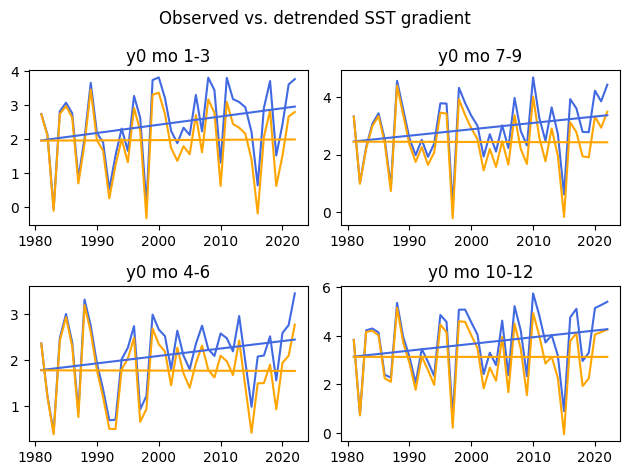

In [31]:
# plot both SST gradients and compare
fig, ax = plt.subplots(2,2)
icol = 0
for i in np.arange(0,2):
    for j in np.arange(0,2):
        tmpindex = np.array(climind82_seasons.iloc[:,icol].index)
        tmpobs = np.array(climind82_seasons.iloc[:,icol])
        tmpDT = np.array(climind82_seasonsDT.iloc[:,icol])
        ax[j,i].plot(tmpindex, tmpobs, label='obs', c='royalblue')
        ax[j,i].plot(tmpindex, tmpDT, label='DT', c='orange')
        ax[j,i].set_title(climind82_seasons.columns[icol])
        # show trendlines
        reg = linregress(tmpindex, tmpobs)
        m = reg.slope
        b = reg.intercept
        regpredict = m*tmpindex + b
        reg2 = linregress(tmpindex, tmpDT)
        m2 = reg2.slope
        b2 = reg2.intercept
        reg2predict = m2*tmpindex + b2
        print('slopes of '+climind83_seasons.columns[icol]+'\t'+'m1: {:.2}\tm2: {:.2}'.format(m, m2))
        ax[j,i].plot(tmpindex, regpredict, label='pos. lin. trend', c='royalblue')
        ax[j,i].plot(tmpindex, reg2predict, label='normalized trend', c='orange')
        icol+=1
fig.suptitle('Observed vs. detrended SST gradient')
fig.tight_layout()

In [32]:
# split the data into the inputs

ant_rolls = int((ant_years+1)*12/ant_season)

# storage; rolling average SSTs
sst_avg_roll = np.zeros((time_length+2, ant_rolls)) # years, rolling periods
labels = [] # labels for each col

icol = 0 # column index
# go through EACH ROLLING PERIOD
for prev in year_rolls:
    years = np.arange(firstyear+prev-2, finalyear+prev+1, 1)
    print(climindname+ ' index from '+str(years[0])+'-'+str(years[-1]))
    for index in np.arange(len(firstmonth)):
        # grab season from df within correct years
        thisseason = 'y0'+' mo ' + str(firstmonth[index])+'-'+str(finalmonth[index] )
        climavg = climind82_seasonsDT.loc[years[0]:years[-1],thisseason]
        # create string description
        label = 'y'+str(prev)+' mo ' + str(firstmonth[index])+'-'+str(finalmonth[index] ) 
        labels.append(label)
        print(label)
        # put this rolling period in the overall storage
        sst_avg_roll[:,icol] = climavg
        icol+=1
# put into dataframe
climind83_seasonsDT = pd.DataFrame(sst_avg_roll, index=None, columns=labels)
print(np.shape(climind83_seasonsDT))

patch125-155_nino3-34d index from 1981-2021
y-1 mo 1-3
y-1 mo 4-6
y-1 mo 7-9
y-1 mo 10-12
patch125-155_nino3-34d index from 1982-2022
y0 mo 1-3
y0 mo 4-6
y0 mo 7-9
y0 mo 10-12
(41, 8)


In [33]:
# save data
climind82_seasonsDT.to_csv('sstgrad_seasonfull_' +climindfilename+'_81_y.txt')
print('exported sstgrad_seasonfull_' +climindfilename+'_81_y.txt')
climind83_seasonsDT.to_csv('sstgrad_seasons_' +climindfilename+'_81_y.txt')
print('exported sstgrad_seasons_' +climindfilename+'_81_y.txt')

# print last time the data was updated
from datetime import datetime

# datetime object containing current date and time
now = datetime.now()
# dd/mm/YY H:M:S
dt_string = now.strftime("%d/%m/%Y %H:%M:%S")
print("Data last updated for",climindname,"=", dt_string)

exported sstgrad_seasonfull_DeTrend_patch125-155_nino3-34d_81_y.txt
exported sstgrad_seasons_DeTrend_patch125-155_nino3-34d_81_y.txt
Data last updated for patch125-155_nino3-34d = 21/10/2025 12:23:53


slopes of y-1 mo 1-3	m1: 0.021	m2: -0.0021
slopes of y-1 mo 4-6	m1: 0.012	m2: -0.004
slopes of y-1 mo 7-9	m1: 0.018	m2: -0.0045
slopes of y-1 mo 10-12	m1: 0.023	m2: -0.0041
slopes of y0 mo 1-3	m1: 0.027	m2: 0.0037
slopes of y0 mo 4-6	m1: 0.018	m2: 0.0018
slopes of y0 mo 7-9	m1: 0.026	m2: 0.0027
slopes of y0 mo 10-12	m1: 0.03	m2: 0.0025


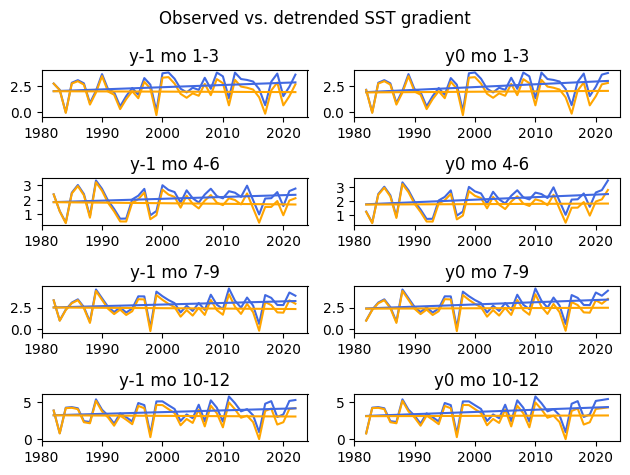

In [34]:
# plot both SST gradients and compare
fig, ax = plt.subplots(4,2)
icol = 0
for i in np.arange(0,2):
    for j in np.arange(0,4):
        tmpobs = np.array(climind83_seasons.iloc[:,icol])
        tmpDT = np.array(climind83_seasonsDT.iloc[:,icol])
        ax[j,i].plot(years, tmpobs, label='obs', c='royalblue')
        ax[j,i].plot(years, tmpDT, label='DT', c='orange')
        ax[j,i].set_title(climind83_seasons.columns[icol])
        # show trendlines
        reg = linregress(years, tmpobs)
        m = reg.slope
        b = reg.intercept
        regpredict = m*years + b
        reg2 = linregress(years, tmpDT)
        m2 = reg2.slope
        b2 = reg2.intercept
        reg2predict = m2*years + b2
        print('slopes of '+climind83_seasons.columns[icol]+'\t'+'m1: {:.2}\tm2: {:.2}'.format(m, m2))
        ax[j,i].plot(years, regpredict, label='pos. lin. trend', c='royalblue')
        ax[j,i].plot(years, reg2predict, label='normalized trend', c='orange')
        icol+=1
fig.suptitle('Observed vs. detrended SST gradient')
fig.tight_layout()

In [35]:
# datetime object containing current date and time
from datetime import datetime
now = datetime.now()
# dd/mm/YY H:M:S
dt_string = now.strftime("%d/%m/%Y %H:%M:%S")
print('SST gradient exported: '+climindname)
print("Last export =", dt_string)

SST gradient exported: patch125-155_nino3-34d
Last export = 21/10/2025 12:23:53


# SST Gradient (average of prior-season and current-season)

(7/22/2024)

Average of prior-season and current-season gSST. Import all the previously-made gSST dataframes, rearrange, and export as its own file so it can be imported into the model for training.

In [36]:
# import
climindfilename = 'DeTrend_'+climindname
print('reading DeTrended '+climindname)
climindseasons82Obs = pd.read_csv('sstgrad_seasons_' +climindname+'_81_y.txt').set_index('Unnamed: 0')
climindseasons82DT = pd.read_csv('sstgrad_seasons_' +climindfilename+'_81_y.txt').set_index('Unnamed: 0')
climindseasons83Obs = pd.read_csv('sstgrad_seasons_' +climindname+'_82_y.txt').set_index('Unnamed: 0')
climindseasons83DT = pd.read_csv('sstgrad_seasons_' +climindfilename+'_82_y.txt').set_index('Unnamed: 0')

reading DeTrended patch125-155_nino3-34d


In [37]:
# (7/19/2024) Get average of prior-season and concurrent-season
# replace the prior-season gSST with gSST_avg

climindseasons82Obs_avg = []
climindseasons82DT_avg = []
climindseasons83Obs_avg = []
climindseasons83DT_avg = []
ncols = len(climindseasons83Obs.columns)

for icol in np.arange(1, ncols):
    tmpcurrent2 = climindseasons82Obs.iloc[:,icol]
    tmpprior2 = climindseasons82Obs.iloc[:,icol-1]
    tmpavg2 = (tmpcurrent2 + tmpprior2)/2

    tmpcurrentDT2 = climindseasons82DT.iloc[:,icol]
    tmppriorDT2 = climindseasons82DT.iloc[:,icol-1]
    tmpavgDT2 = (tmpcurrentDT2 + tmppriorDT2)/2
    
    tmpcurrent3 = climindseasons83Obs.iloc[:,icol]
    tmpprior3 = climindseasons83Obs.iloc[:,icol-1]
    tmpavg3 = (tmpcurrent3 + tmpprior3)/2

    tmpcurrentDT3 = climindseasons83DT.iloc[:,icol]
    tmppriorDT3 = climindseasons83DT.iloc[:,icol-1]
    tmpavgDT3 = (tmpcurrentDT3 + tmppriorDT3)/2
    # add to a list
    climindseasons82Obs_avg.append(tmpavg2.to_list())
    climindseasons82DT_avg.append(tmpavgDT2.to_list())
    climindseasons83Obs_avg.append(tmpavg3.to_list())
    climindseasons83DT_avg.append(tmpavgDT3.to_list())

# column names now with the averages of the seasons
avglabels = ['y-1 mo 1-6', 'y-1 mo 4-9', 'y-1 mo 7-12',
             'y-1 mo 10-3', 'y0 mo 1-6', 'y0 mo 4-9', 
             'y0 mo 7-12']

climindseasons82Obs_avgdf = pd.DataFrame(np.array(climindseasons82Obs_avg).transpose(), index=climindseasons82Obs.index, columns=avglabels)
climindseasons82DT_avgdf = pd.DataFrame(np.array(climindseasons82DT_avg).transpose(), index=climindseasons82DT.index, columns=avglabels)
climindseasons83Obs_avgdf = pd.DataFrame(np.array(climindseasons83Obs_avg).transpose(), index=climindseasons83Obs.index, columns=avglabels)
climindseasons83DT_avgdf = pd.DataFrame(np.array(climindseasons83DT_avg).transpose(), index=climindseasons83DT.index, columns=avglabels)

In [38]:
# export
# save data
climindseasons82Obs_avgdf.to_csv('sstgrad_seasons_' +climindname+'_81_y_avgcurr-prior.txt')
print('exported sstgrad_seasonfull_' +climindfilename+'_81_y_avgcurr-prior.txt')
climindseasons82DT_avgdf.to_csv('sstgrad_seasons_' +climindfilename+'_81_y_avgcurr-prior.txt')
print('exported sstgrad_seasons_' +climindfilename+'_81_y_avgcurr-prior.txt')
climindseasons83Obs_avgdf.to_csv('sstgrad_seasons_' +climindname+'_82_y_avgcurr-prior.txt')
print('exported sstgrad_seasonfull_' +climindfilename+'_82_y_avgcurr-prior.txt')
climindseasons83DT_avgdf.to_csv('sstgrad_seasons_' +climindfilename+'_82_y_avgcurr-prior.txt')
print('exported sstgrad_seasons_' +climindfilename+'_82_y_avgcurr-prior.txt')

# print last time the data was updated
from datetime import datetime

# datetime object containing current date and time
now = datetime.now()
# dd/mm/YY H:M:S
dt_string = now.strftime("%d/%m/%Y %H:%M:%S")
print("Data last updated for",climindname,"=", dt_string)

exported sstgrad_seasonfull_DeTrend_patch125-155_nino3-34d_81_y_avgcurr-prior.txt
exported sstgrad_seasons_DeTrend_patch125-155_nino3-34d_81_y_avgcurr-prior.txt
exported sstgrad_seasonfull_DeTrend_patch125-155_nino3-34d_82_y_avgcurr-prior.txt
exported sstgrad_seasons_DeTrend_patch125-155_nino3-34d_82_y_avgcurr-prior.txt
Data last updated for patch125-155_nino3-34d = 21/10/2025 12:23:53


<Axes: xlabel='Unnamed: 0'>

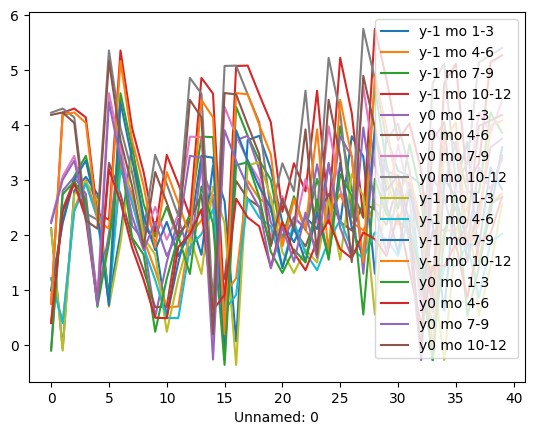

In [39]:
fig, ax = plt.subplots()

climindseasons83Obs.plot(ax=ax)
climindseasons83DT.plot(ax=ax)